In [1]:
import vitaldb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import resample_poly

In [2]:
# Find cases containing arterial pressure
abp_cases = vitaldb.find_cases(['ART'])

print("Cases with ART:", len(abp_cases))
print(abp_cases[:20])

/tmp/ipykernel_4052/3920463723.py:2: DeprecationWarning: find_cases() relies on the per-track 'trks' index, which is deprecated and may be removed in a future release.
  abp_cases = vitaldb.find_cases(['ART'])


Cases with ART: 3645
[1, 3, 4, 7, 10, 12, 13, 14, 16, 17, 19, 20, 22, 24, 25, 26, 27, 28, 29, 31]


In [3]:
ppg_cases = vitaldb.find_cases(['PLETH'])

print("Cases with PLETH:", len(ppg_cases))
print(ppg_cases[:20])

Cases with PLETH: 6157
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14, 15, 16, 17, 18, 19, 20, 21]


/tmp/ipykernel_4052/195122844.py:1: DeprecationWarning: find_cases() relies on the per-track 'trks' index, which is deprecated and may be removed in a future release.
  ppg_cases = vitaldb.find_cases(['PLETH'])


In [4]:
common_cases = sorted(
    set(abp_cases).intersection(ppg_cases)
)

print("Cases with both PPG and ABP:", len(common_cases))
print(common_cases[:20])

Cases with both PPG and ABP: 3459
[1, 3, 4, 7, 10, 13, 14, 16, 17, 19, 20, 22, 24, 25, 26, 27, 28, 29, 31, 32]


In [5]:
case_id = common_cases[10]
vf = vitaldb.VitalFile(case_id)
data = vf.to_numpy(
    [
        "SNUADC/PLETH",
        "SNUADC/ART"
    ],
    interval=1/500
)

ppg = data[:, 0]
art = data[:, 1]

print("Data shape:", data.shape)
print("PPG shape:", ppg.shape)
print("ART shape:", art.shape)

Data shape: (13237788, 2)
PPG shape: (13237788,)
ART shape: (13237788,)


In [6]:
vf = vitaldb.VitalFile(case_id)

tracks = vf.get_track_names()

for track in tracks:
    if 'PLETH' in track.upper() or 'ART' in track.upper():
        print(track)

Solar8000/ART_MBP
Solar8000/ART_SBP
Solar8000/ART_DBP
Solar8000/PLETH_SPO2
Solar8000/PLETH_HR
SNUADC/ART
SNUADC/PLETH


In [7]:
ppg_track = vf.trks["SNUADC/PLETH"]
art_track = vf.trks["SNUADC/ART"]

print("PPG sampling rate:", ppg_track.srate)
print("ART sampling rate:", art_track.srate)

PPG sampling rate: 500.0
ART sampling rate: 500.0


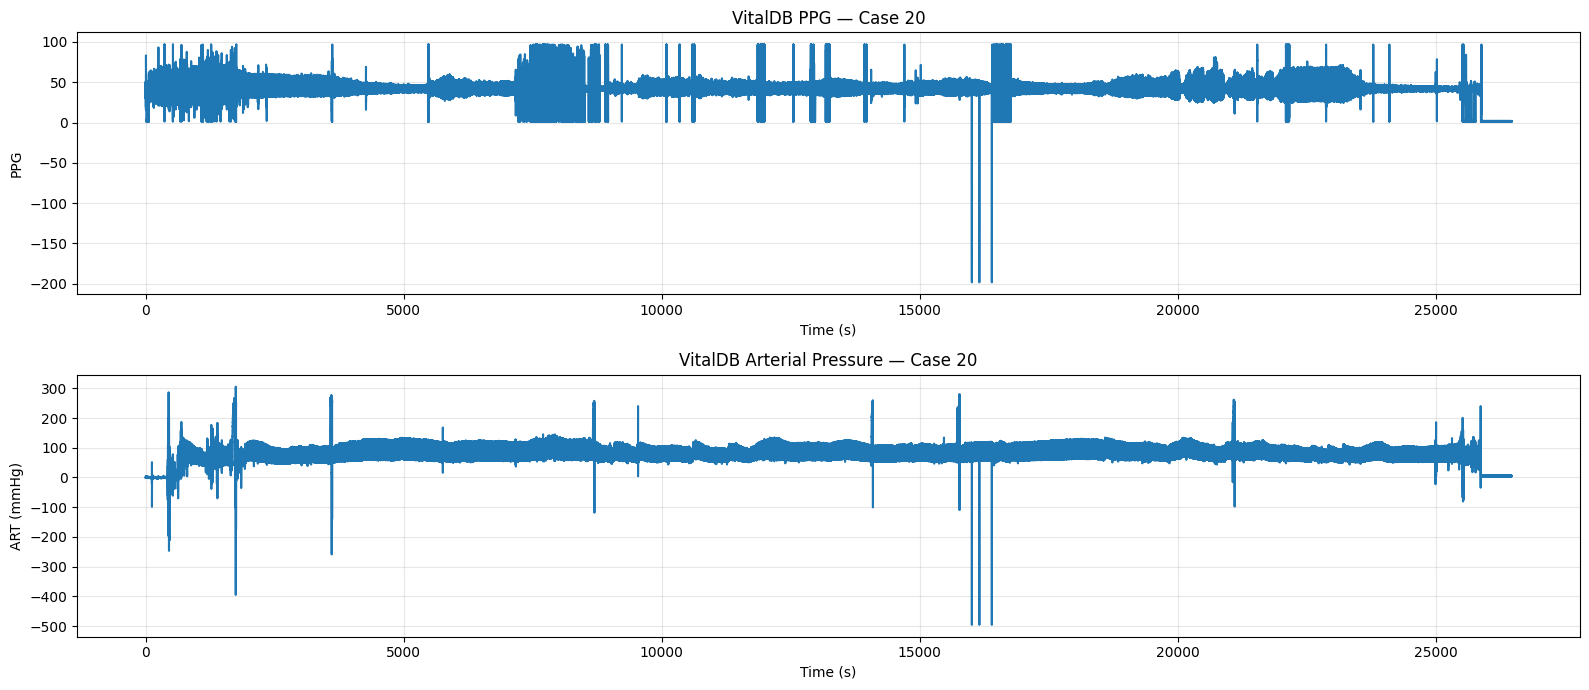

In [8]:
fs = 500

N = len(ppg)

time = np.arange(N) / fs

plt.figure(figsize=(16, 7))

plt.subplot(2, 1, 1)

plt.plot(
    time,
    ppg
)

plt.xlabel("Time (s)")
plt.ylabel("PPG")
plt.title(f"VitalDB PPG — Case {case_id}")
plt.grid(alpha=0.3)


plt.subplot(2, 1, 2)

plt.plot(
    time,
    art
)

plt.xlabel("Time (s)")
plt.ylabel("ART (mmHg)")
plt.title(f"VitalDB Arterial Pressure — Case {case_id}")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

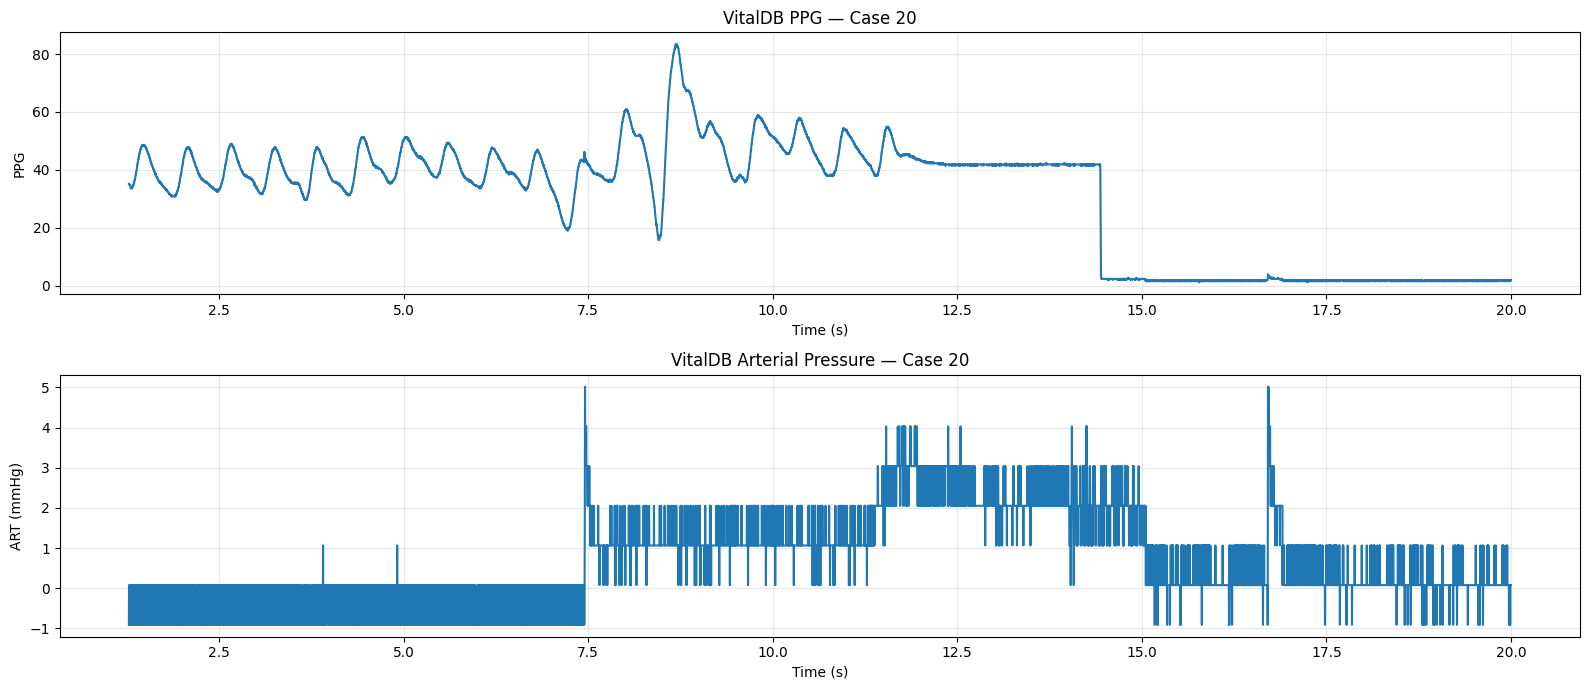

In [9]:
fs = 500
duration = 20

N = int(fs * duration)

time = np.arange(N) / fs

plt.figure(figsize=(16, 7))

plt.subplot(2, 1, 1)

plt.plot(
    time,
    ppg[:N]
)

plt.xlabel("Time (s)")
plt.ylabel("PPG")
plt.title(f"VitalDB PPG — Case {case_id}")
plt.grid(alpha=0.3)


plt.subplot(2, 1, 2)

plt.plot(
    time,
    art[:N]
)

plt.xlabel("Time (s)")
plt.ylabel("ART (mmHg)")
plt.title(f"VitalDB Arterial Pressure — Case {case_id}")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [11]:
print("PPG:")
print("min =", np.nanmin(ppg))
print("max =", np.nanmax(ppg))
print("mean =", np.nanmean(ppg))
print("std =", np.nanstd(ppg))

print("\nABP:")
print("min =", np.nanmin(art))
print("max =", np.nanmax(art))
print("mean =", np.nanmean(art))
print("std =", np.nanstd(art))

PPG:
min = -198.2504
max = 97.19675
mean = 39.908978
std = 11.125543

ABP:
min = -495.626
max = 305.20163
mean = 75.18822
std = 28.148708


## Downsampling ##

Vital DB dataset is sampled at 500Hz but UCI is at 125Hz. For zero-shot learning we thus need to downsample vital db dataset

In [12]:
def downsample_signal(signal, original_fs=500, target_fs=125):
    signal = np.asarray(signal, dtype=np.float32)

    # 500 Hz → 125 Hz = downsample by 4
    downsampled = resample_poly(
        signal,
        up=1,
        down=4
    )

    return downsampled.astype(np.float32)

In [ ]:
ppg_500 = ppg  # 8 sec at 500 Hz
art_500 = art

ppg_125 = downsample_signal(
    ppg_500
)

print("Original shape:", ppg_500.shape)
print("Downsampled shape:", ppg_125.shape)


Original shape: (13237788,)
Downsampled shape: (3309447,)
Original shape: (13237788,)
Downsampled shape: (3309447,)


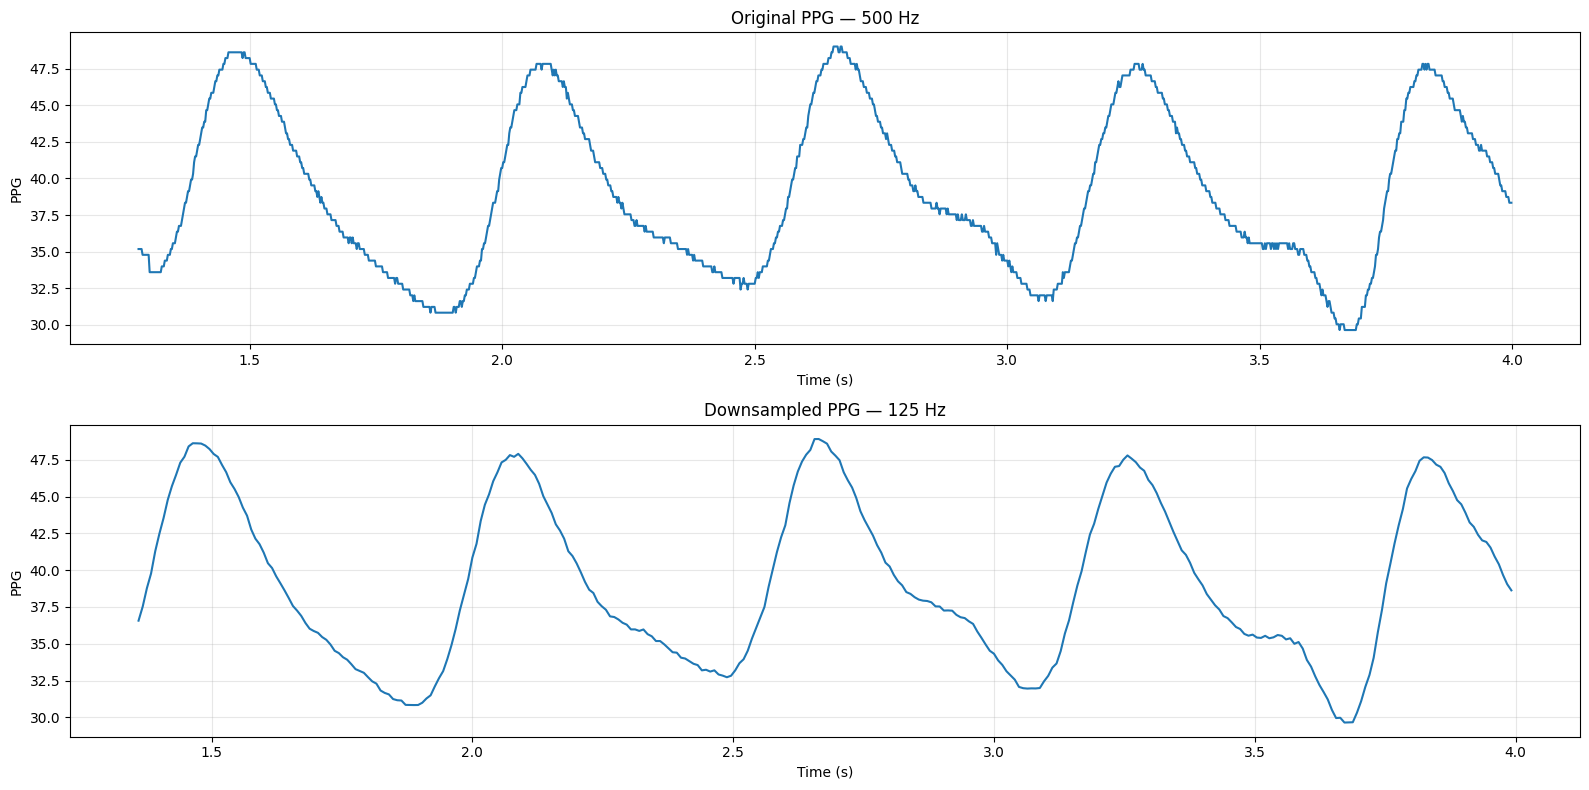

In [31]:
fs_original = 500
fs = 125

time_original = np.arange(len(ppg)) / fs_original
time = np.arange(len(ppg_125)) / fs

plt.figure(figsize=(16, 8))

# -----------------------------------------
# Original PPG
# -----------------------------------------
plt.subplot(2, 1, 1)

plt.plot(
    time_original[:2000],
    ppg[:2000]
)

plt.xlabel("Time (s)")
plt.ylabel("PPG")
plt.title("Original PPG — 500 Hz")
plt.grid(alpha=0.3)


# -----------------------------------------
# Downsampled PPG
# -----------------------------------------
plt.subplot(2, 1, 2)

plt.plot(
    time[:500],
    ppg_125[:500]
)

plt.xlabel("Time (s)")
plt.ylabel("PPG")
plt.title("Downsampled PPG — 125 Hz")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()